In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math

# We'll generate sequences with numbers from 0 up to max_val-1
max_val = 30

def generate_data(batch_size, seq_len, max_val):
    """
    Generates batches of unsorted sequences and their sorted counterparts.
    """
    # Generate random sequences of integers, drawing without replacement
    # to ensure unique values in each sequence.
    inputs = torch.empty((batch_size, seq_len), dtype=torch.int64)
    for i in range(batch_size):
        # torch.randperm(n) gives a random permutation of integers from 0 to n-1.
        inputs[i] = torch.randperm(max_val)[:seq_len]
    
    # Sort each sequence to get the target labels.
    labels = torch.sort(inputs, dim=1).values
    return inputs, labels

# Let's see an example
inputs, labels = generate_data(batch_size=2, seq_len=10, max_val=max_val)
print("Inputs:\n", inputs)
print("\nLabels (Sorted Inputs):\n", labels)

Inputs:
 tensor([[ 8, 10, 11,  4, 22, 25, 29, 16,  6, 27],
        [ 5, 22,  4, 20, 11, 10,  7, 19,  0,  6]])

Labels (Sorted Inputs):
 tensor([[ 4,  6,  8, 10, 11, 16, 22, 25, 27, 29],
        [ 0,  4,  5,  6,  7, 10, 11, 19, 20, 22]])


In [2]:
class RnnSorter(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        # Use an embedding layer to represent numbers as vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # The RNN encoder
        self.rnn = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        # A linear layer to map the output hidden states to our vocab
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.embedding(x)
        # embedded shape: [batch_size, seq_len, embedding_dim]
        
        # We pass the entire sequence of embeddings to the GRU.
        output, _ = self.rnn(embedded)
        # output shape: [batch_size, seq_len, hidden_dim]
        
        # We apply the linear layer to each time step's output.
        logits = self.fc(output)
        # logits shape: [batch_size, seq_len, vocab_size]
        return logits

In [3]:
# Model parameters
epochs = 100
batch_size = 32
embedding_dim = 16
hidden_dim = 32

# Instantiate the model, loss function, and optimizer
model_rnn = RnnSorter(vocab_size=max_val, embedding_dim=embedding_dim, hidden_dim=hidden_dim)
loss_fn_rnn = nn.CrossEntropyLoss()
optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=0.001)

print(f"Num of parameters in RNN model: {sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)}")

print("\n--- Training RNN (for a few epochs to see loss) ---")
for epoch in range(epochs):
    optimizer_rnn.zero_grad()
    inputs, labels = generate_data(batch_size=batch_size, seq_len=10, max_val=max_val)
    
    # Forward pass
    outputs = model_rnn(inputs)
    
    # Loss function expects shape [N, C], so we reshape our outputs and labels
    # from [batch, seq_len, vocab] to [batch*seq_len, vocab]
    loss = loss_fn_rnn(outputs.view(-1, max_val), labels.view(-1))
    
    # Backward pass and optimization
    loss.backward()
    optimizer_rnn.step()
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Num of parameters in RNN model: 6270

--- Training RNN (for a few epochs to see loss) ---
Epoch 0, Loss: 3.4376
Epoch 10, Loss: 3.4165
Epoch 20, Loss: 3.3907
Epoch 30, Loss: 3.3798
Epoch 40, Loss: 3.3776
Epoch 50, Loss: 3.3628
Epoch 60, Loss: 3.3469
Epoch 70, Loss: 3.3371
Epoch 80, Loss: 3.3010
Epoch 90, Loss: 3.2883


In [ ]:
class SelfAttentionBlock(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert self.head_dim * num_heads == self.embed_dim, "embed_dim must be divisible by num_heads"

        self.qkv_proj = nn.Linear(embed_dim, embed_dim * 3)
        self.output_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        # x shape: [batch_size, seq_len, embed_dim]
        B, L, E = x.shape
        
        # 1. Project to Q, K, V and split into heads
        # qkv shape: [B, L, E*3] -> [B, L, 3, num_heads, head_dim] -> [3, B, num_heads, L, head_dim]
        q, k, v = self.qkv_proj(x).reshape(B, L, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        
        # --- STUDENT TO IMPLEMENT ---
        # 2. Calculate attention scores by multiplying queries and keys.
        #    The shape of q is [B, num_heads, L, head_dim]
        #    The shape of k is [B, num_heads, L, head_dim]
        #    We need to multiply them to get a shape of [B, num_heads, L, L]
        #    Hint: Use .transpose(-2, -1) on k.
        attn_scores = q @ k.transpose(-2, -1)
        # 3. Scale the scores to stabilize training.
        #    Divide the scores by the square root of the head dimension.
        attn_scores = attn_scores / math.sqrt(self.head_dim)
        
        # 4. Apply softmax to the scores to get attention weights.
        #    The softmax should be applied on the last dimension (dim=-1).
        attn_weights = torch.softmax(attn_scores, dim=-1)
        
        # 5. Get the context vector by multiplying the attention weights with V.
        #    The shape of attn_weights is [B, num_heads, L, L]
        #    The shape of v is [B, num_heads, L, head_dim]
        #    The resulting shape should be [B, num_heads, L, head_dim]
        context = attn_weights @ v
        # --- END OF STUDENT IMPLEMENTATION ---
        
        # 6. Concatenate heads and project output
        context = context.transpose(1, 2).reshape(B, L, E)
        output = self.output_proj(context)
        
        return output, attn_weights # Return weights for visualization!

In [17]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=50): # Increased max_len for safety
        super().__init__()
        # Create a positional encoding matrix of shape [max_len, embed_dim]
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-torch.log(torch.tensor(10000.0)) / embed_dim))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Add a batch dimension so it can be easily added to the input embeddings
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x shape: [batch_size, seq_len, embed_dim]
        # Add the positional encoding to the input embeddings
        x = x + self.pe[:, :x.size(1), :]
        return x

In [18]:
class AttentionSorter(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim)
        self.attention_block = SelfAttentionBlock(embed_dim, num_heads)
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        embedded = self.embedding(x)
        embedded_with_pos = self.positional_encoding(embedded)
        # embedded_with_pos shape: [batch_size, seq_len, embed_dim]
        
        attn_output, attn_weights = self.attention_block(embedded_with_pos)
        # attn_output shape: [batch_size, seq_len, embed_dim]
        
        logits = self.fc(attn_output)
        # logits shape: [batch_size, seq_len, vocab_size]
        
        return logits, attn_weights

In [19]:
# Model parameters
epochs_attn = 10000
batch_size_attn = 64
embed_dim_attn = 16
num_heads_attn = 4

# Instantiate the model, loss function, and optimizer
model_attention = AttentionSorter(vocab_size=max_val, embed_dim=embed_dim_attn, num_heads=num_heads_attn)
loss_fn_attention = nn.CrossEntropyLoss()
optimizer_attention = torch.optim.Adam(model_attention.parameters(), lr=0.001)

print(f"Num of parameters in Attention model: {sum(p.numel() for p in model_attention.parameters() if p.requires_grad)}")

print("\n--- Training Attention Model ---")
for epoch in range(epochs_attn):
    optimizer_attention.zero_grad()
    inputs, labels = generate_data(batch_size=batch_size_attn, seq_len=10, max_val=max_val)
    
    # Forward pass
    outputs, attn_weights = model_attention(inputs)
    
    # Compute loss
    loss = loss_fn_attention(outputs.view(-1, max_val), labels.view(-1))
    
    # Backward pass and optimization
    loss.backward()
    optimizer_attention.step()
    
    if epoch % 300 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Num of parameters in Attention model: 2078

--- Training Attention Model ---


RuntimeError: Expected size for first two dimensions of batch2 tensor to be: [256, 4] but got: [256, 10].

In [12]:
def evaluate_model(model, model_type='attention'):
    """Evaluates the model on a new batch of data and returns accuracy."""
    model.eval() # Set model to evaluation mode
    test_inputs, test_labels = generate_data(batch_size=1000, seq_len=10, max_val=max_val)
    
    with torch.no_grad():
        if model_type == 'attention':
            outputs, _ = model(test_inputs)
        else: # rnn
            outputs = model(test_inputs)
            
        # Get the predicted class (the number) for each position
        predicted_indices = torch.argmax(outputs, dim=2)
        
        # Compare predictions to the true labels
        correct = (predicted_indices == test_labels).float().sum()
        total_elements = test_labels.numel()
        accuracy = correct / total_elements
    return accuracy.item()

In [13]:
# Evaluate both models
accuracy_rnn = evaluate_model(model_rnn, model_type='rnn')
accuracy_attention = evaluate_model(model_attention, model_type='attention')

print(f'\n--- Final Results ---')
print(f'RNN Model Accuracy: {accuracy_rnn*100:.2f}%')
print(f'Attention Model Accuracy: {accuracy_attention*100:.2f}%')


--- Final Results ---
RNN Model Accuracy: 6.39%
Attention Model Accuracy: 94.19%


In [14]:
def visualize_attention(model, num_to_vis=1):
    model.eval()
    inputs, labels = generate_data(batch_size=num_to_vis, seq_len=10, max_val=max_val)
    
    with torch.no_grad():
        _, attn_weights = model(inputs)
    
    # attn_weights shape: [batch, num_heads, seq_len, seq_len]
    attn_weights = attn_weights.cpu()
    
    for i in range(num_to_vis):
        # We can average the weights across all heads for a simpler view
        avg_attn_weights = attn_weights[i].mean(dim=0)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(avg_attn_weights, cmap='viridis')

        input_labels = [str(x.item()) for x in inputs[i]]
        output_labels = [str(x.item()) for x in inputs[i]]
        
        ax.set_xticks(range(len(input_labels)))
        ax.set_yticks(range(len(output_labels)))
        ax.set_xticklabels(input_labels)
        ax.set_yticklabels(output_labels)
        
        plt.xlabel("Keys")
        plt.ylabel("Queries")
        plt.title(f"Averaged Attention Weights for Input: {input_labels}")
        fig.colorbar(im, ax=ax)
        plt.show()

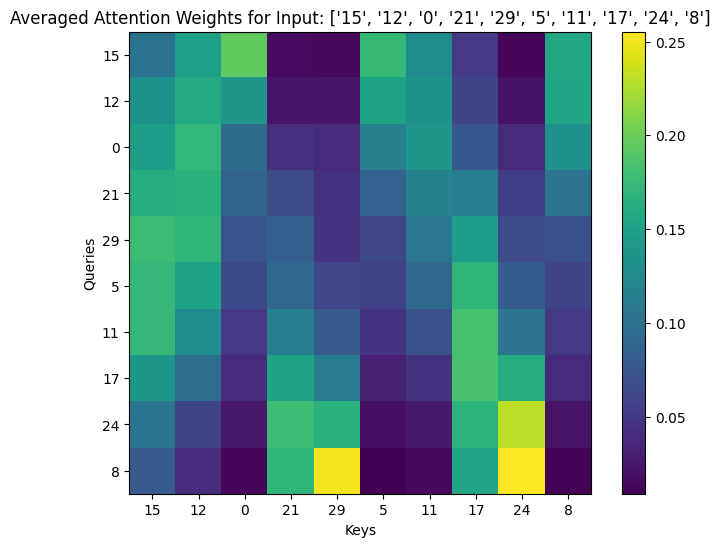

In [15]:
visualize_attention(model_attention)
